# Clasificador de Vinos con KNN

## Descripción de las columnas
Cada fila representa un vino. Las columnas describen su composición química:

fixed acidity, volatile acidity, citric acid

residual sugar, chlorides

free sulfur dioxide, total sulfur dioxide

density, pH, sulphates, alcohol

La columna objetivo es label:

0 = Baja calidad

1 = Calidad media

2 = Alta calidad

## Carga de datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/winequality-red.csv', sep= ';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


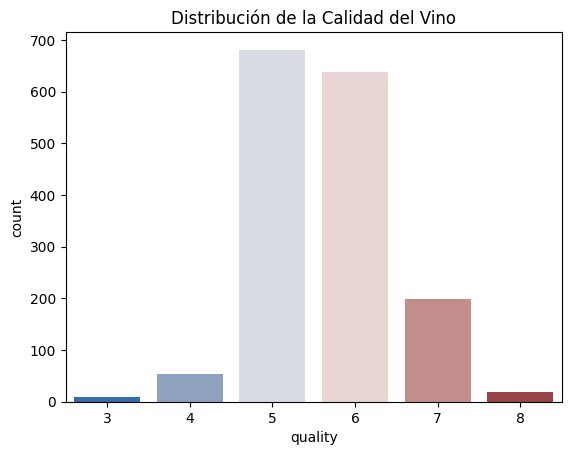

In [5]:
sns.countplot(x='quality', data=df, hue='quality', palette='vlag', legend=False)
plt.title('Distribución de la Calidad del Vino')
plt.show()

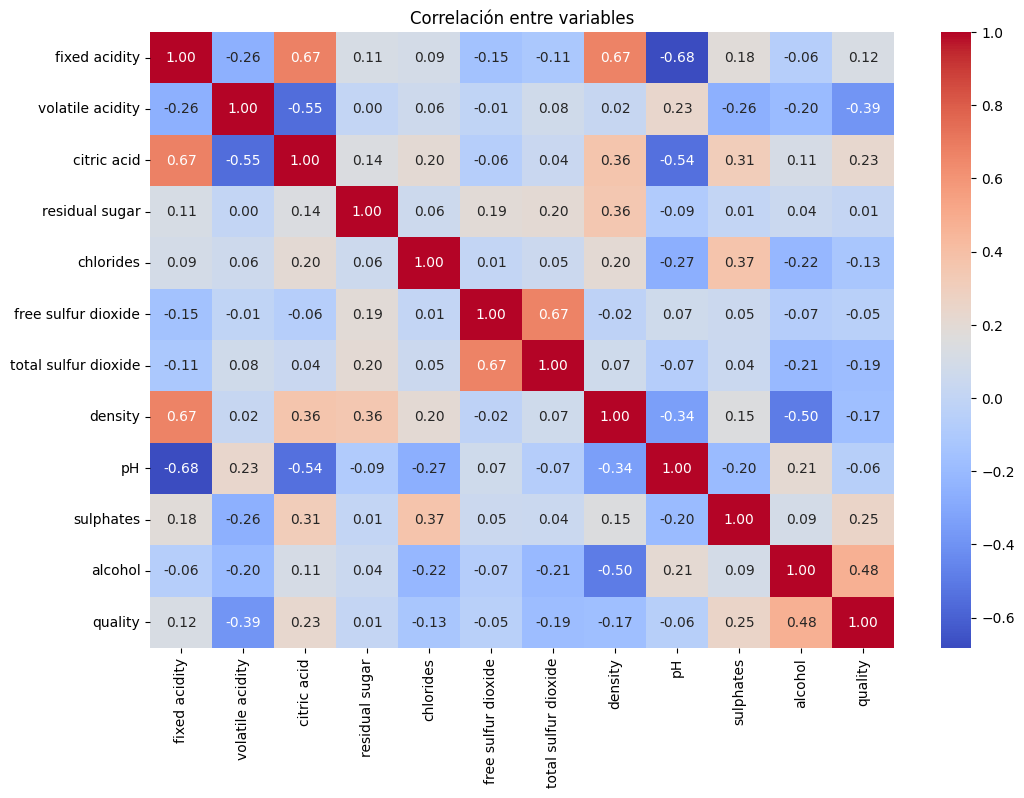

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre variables')
plt.show()

Es muy importante en la calidad del vino el porcentaje de alcohol y la acidez volátil y en segundo lugar los sulfatos, el ácido cítrico y el dióxido de sulfuro.

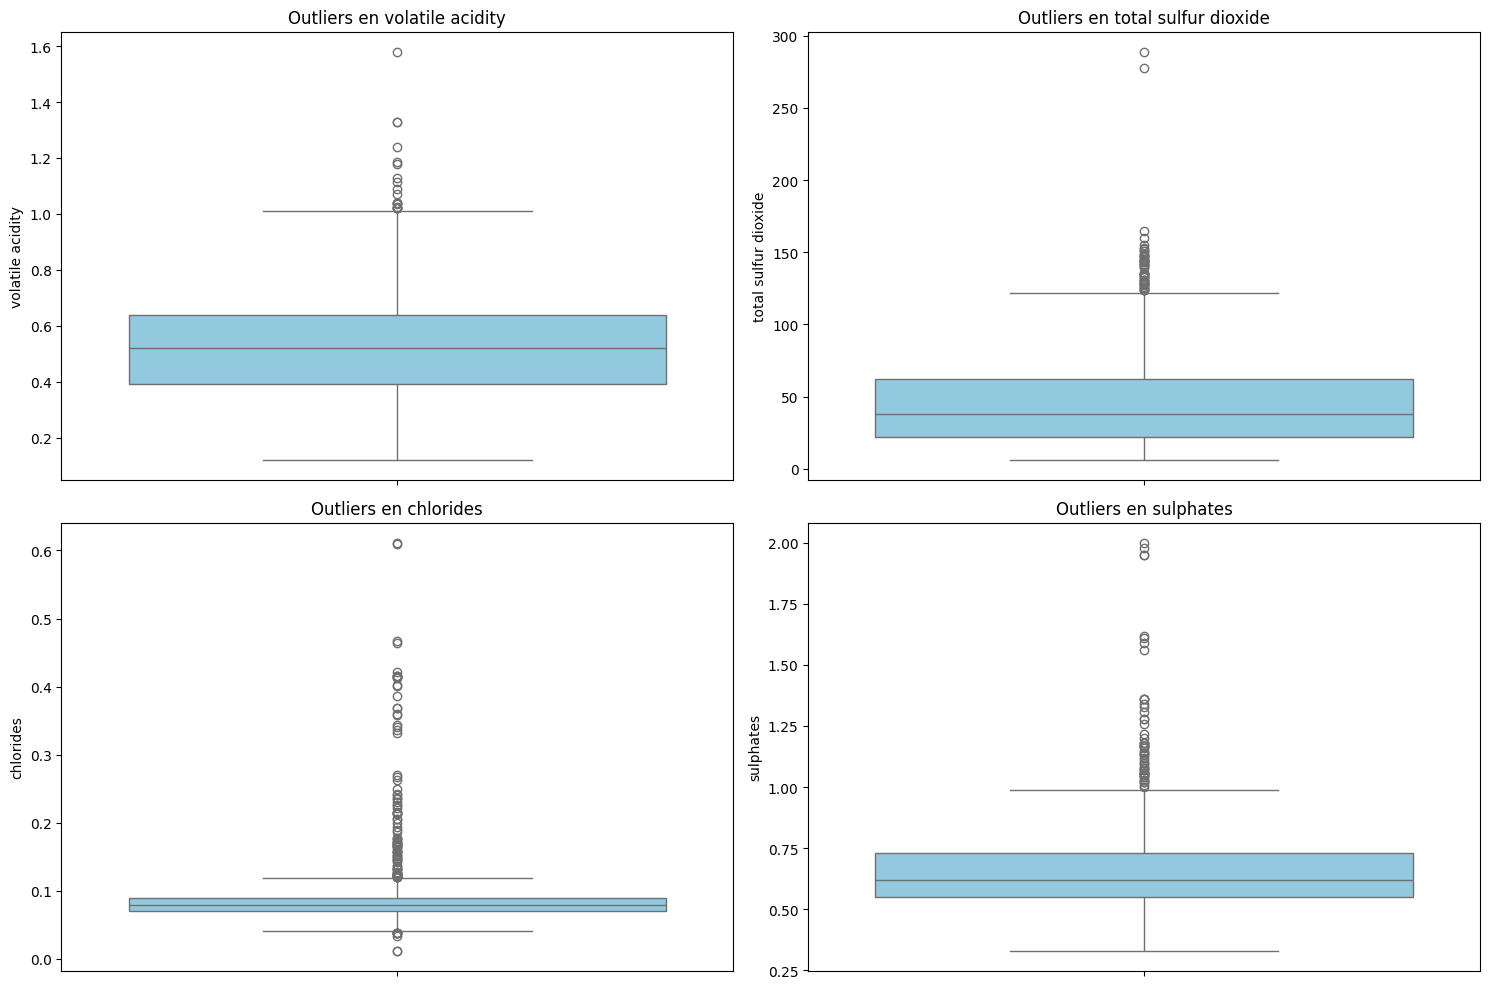

In [7]:
plt.figure(figsize=(15, 10))
cols = ['volatile acidity', 'total sulfur dioxide', 'chlorides', 'sulphates']
for i, col in enumerate(cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers en {col}')
plt.tight_layout()
plt.show()

## Preparación y escalado

In [8]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ¡Paso vital para KNN!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Optimización de K (El bucle)

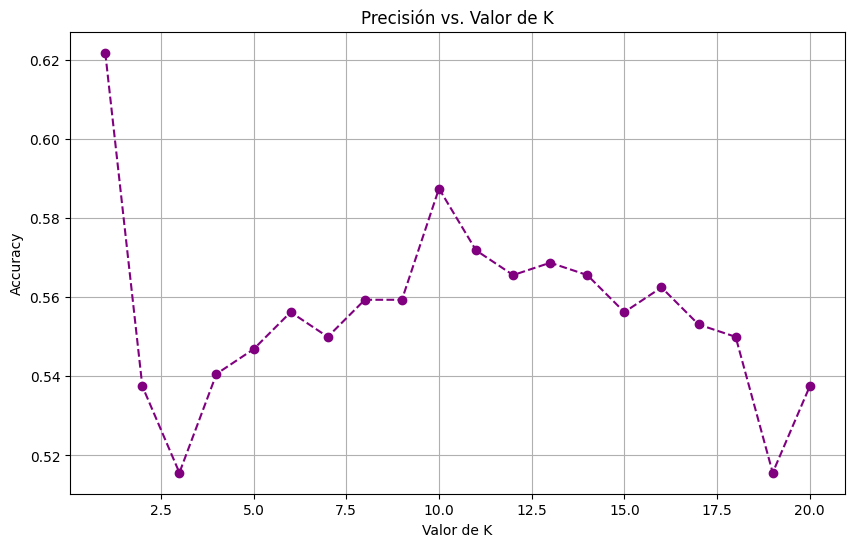

El mejor valor de k es: 1


In [9]:
accuracies = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

# Gráfica Visual
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='purple')
plt.title('Precisión vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Elegimos el mejor k (el que tenga mayor accuracy)
best_k = k_range[np.argmax(accuracies)]
print(f"El mejor valor de k es: {best_k}")

La gráfica tiene una forma de "W": empieza alto en k=1, cae en picado hasta k=3, y luego sube hasta alcanzar su segundo pico importante en k=10.

K=1 es un espejismo: Ese 0.62 inicial es pura memorización (overfitting). Si usáramos ese modelo con vinos nuevos, fallaría mucho más.

K=10 es el punto dulce: Es el valor más alto y estable después de la caída inicial. Significa que, al promediar con 10 vecinos, el ruido de los outliers se suaviza y el modelo clasifica mejor.

Baja resolución general: Un accuracy de 0.58 sugiere que el modelo KNN está teniendo dificultades para distinguir entre calidades muy parecidas (como un vino de 5 y uno de 6). Esto es normal en este dataset si no se limpian los valores extremos.

De todos modos, el KNN por sí solo se queda corto porque trata a todas las variables por igual.


In [10]:
# Eliminamos el ruido extremo (Outliers)
q_limit = df["total sulfur dioxide"].quantile(0.99)
df_clean = df[df["total sulfur dioxide"] < q_limit]

In [11]:
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ¡Paso vital para KNN!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

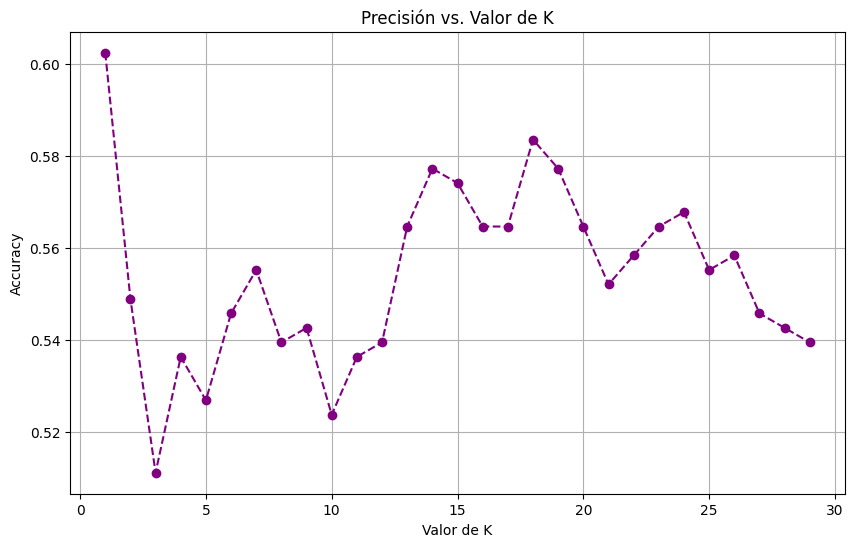

El mejor valor de k es: 1


In [12]:
accuracies = []
k_range = range(1, 30)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

# Gráfica Visual
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='purple')
plt.title('Precisión vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Elegimos el mejor k (el que tenga mayor accuracy)
best_k = k_range[np.argmax(accuracies)]
print(f"El mejor valor de k es: {best_k}")

Es notable cómo cambia sólo con la eliminación de unos pocos outliers.

Zona de estabilidad: Entre K 14 y 19 están los mejores resultados. Esto es mucho más confiable que un pico aislado como el de K=10 anterior. No obstante, el accuracy es muy bajo porque toma todas las variables con el mismo peso.

## Eliminación de variables de baja correlación

In [13]:
df_limpio = df_clean.drop(columns=['residual sugar', 'free sulfur dioxide', 'pH', 'fixed acidity'])

# 2. Reemplazamos los valores de quality
# 3, 4 -> 0
# 5, 6 -> 1
# 7, 8 -> 2
mapeo_calidad = {3: 0, 4: 0, 5: 0, 6: 1, 7: 2, 8: 2}
df_limpio['quality'] = df_limpio['quality'].map(mapeo_calidad)

# Resultado
print(df_limpio.head())

   volatile acidity  citric acid  chlorides  total sulfur dioxide  density  \
0              0.70         0.00      0.076                  34.0   0.9978   
1              0.88         0.00      0.098                  67.0   0.9968   
2              0.76         0.04      0.092                  54.0   0.9970   
3              0.28         0.56      0.075                  60.0   0.9980   
4              0.70         0.00      0.076                  34.0   0.9978   

   sulphates  alcohol  quality  
0       0.56      9.4        0  
1       0.68      9.8        0  
2       0.65      9.8        0  
3       0.58      9.8        1  
4       0.56      9.4        0  


In [14]:
X = df_limpio.drop('quality', axis=1)
y = df_limpio['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ¡Paso vital para KNN!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Debido al desbalance se usará weights='distance'

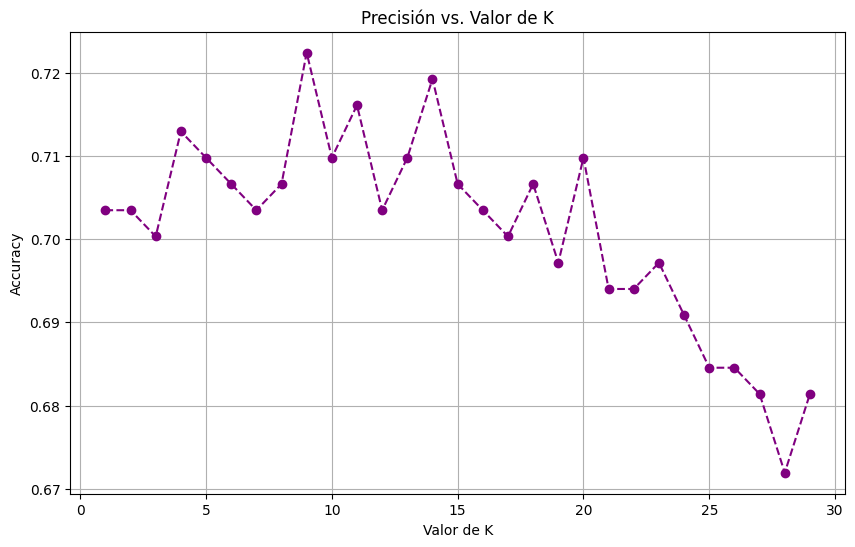

El mejor valor de k es: 9


In [15]:
accuracies = []
k_range = range(1, 30)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

# Gráfica Visual
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='purple')
plt.title('Precisión vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Elegimos el mejor k (el que tenga mayor accuracy)
best_k = k_range[np.argmax(accuracies)]
print(f"El mejor valor de k es: {best_k}")

Es notable cómo mejora con la eliminación de las variables que no tienen mucha correlación y reagrupamos las clases de quality.

Zona de estabilidad: Entre K 9 y 14 están los mejores resultados.

Se usara k=9 porque ser mejor, además es impar para evitar empates en la votación de los vecinos, lo cual es vital en clasificación.

------------------------------
RESULTADOS CON K = 9
------------------------------
Accuracy Score: 0.7224

Matriz de Confusión:
[[115  29   3]
 [ 23  88  13]
 [  3  17  26]]

Reporte de Clasificación:
              precision    recall  f1-score   support

    Baja (0)       0.82      0.78      0.80       147
   Media (1)       0.66      0.71      0.68       124
    Alta (2)       0.62      0.57      0.59        46

    accuracy                           0.72       317
   macro avg       0.70      0.69      0.69       317
weighted avg       0.72      0.72      0.72       317



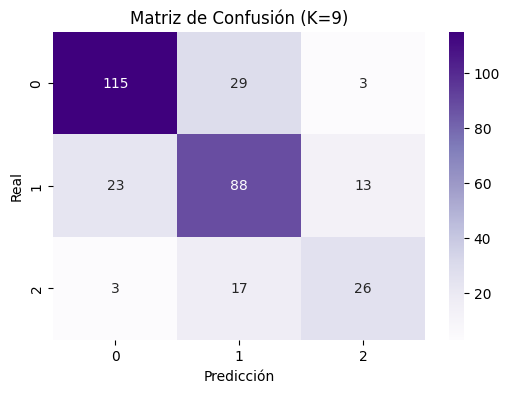

In [20]:
from sklearn.metrics import confusion_matrix

# 1. Entrenamos el modelo final con el mejor k encontrado
knn_final = KNeighborsClassifier(n_neighbors=9, weights='distance')
knn_final.fit(X_train_scaled, y_train)

# 2. Realizamos las predicciones sobre el set de prueba
y_pred = knn_final.predict(X_test_scaled)

# 3. Generamos y mostramos las métricas
print("-" * 30)
print(f"RESULTADOS CON K = {9}")
print("-" * 30)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Baja (0)', 'Media (1)', 'Alta (2)']))

# Opcional: Visualizar la matriz de confusión más clara
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['0','1','2'], yticklabels=['0','1','2'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de Confusión (K={9})')
plt.show()

## La función de predicción "Sommelier IA"

In [21]:
X = df_limpio.drop('quality', axis=1)
y = df_limpio['quality']

# 2. Re-entrenamos el escalador y el modelo final con k=17
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_final = KNeighborsClassifier(n_neighbors=17)
model_final.fit(X_scaled, y)


def predict_wine_quality(features):
    features_df = pd.DataFrame([features], columns=X.columns)
    
    features_scaled = scaler.transform(features_df)
    prediction = model_final.predict(features_scaled)[0] # Tomamos el valor
    
    if prediction == 2:
        return f"Calidad {prediction}: ¡Espectacular! Este vino es una joya. 🥂"
    elif prediction == 1:
        return f"Calidad {prediction}: Un vino de calidad media, ideal para diario. 🍷"
    else:
        return f"Calidad {prediction}: Mmm... quizás mejor para cocinar. 🍳"

# Probamos eliminando del vino de prueba los valores de azúcar, dióxido de sulfuro libre, acidez fija y pH
test_wine = [0.7, 0.0, 0.076, 34.0, 0.9978, 0.56, 9.4]
print(predict_wine_quality(test_wine))


Calidad 0: Mmm... quizás mejor para cocinar. 🍳
